In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [3]:
energy = pd.read_csv(r'C:\PV\cleaned_data\apu_energy.csv');
energy.head()

,Log Type,System,TimeStamp,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
0,APU Energy,APU 1,2025-10-01 00:00:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2599,1287273.0,826.2931,451749.4,1054.821,412543.7,95.27699,306165.9,47.69901,47539.22
1,APU Energy,APU 1,2025-10-01 00:01:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2609,1287273.0,826.2931,451749.4,1054.821,412543.7,95.27699,306165.9,47.69901,47539.22
2,APU Energy,APU 1,2025-10-01 00:02:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2609,1287273.0,826.2931,451749.4,1054.822,412543.7,95.27699,306165.9,47.69901,47539.22
3,APU Energy,APU 1,2025-10-01 00:03:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2609,1287273.0,826.2941,451749.4,1054.822,412543.7,95.27699,306165.9,47.69901,47539.22
4,APU Energy,APU 1,2025-10-01 00:04:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2619,1287273.0,826.2941,451749.4,1054.823,412543.7,95.27699,306165.9,47.69901,47539.22


In [5]:
energy.duplicated().sum()

np.int64(74)

In [12]:
energy.columns

Index(['Log Type', 'System', 'TimeStamp', 'CH 1 pos/Ah', 'CH 1 neg/Ah',
       'CH 2 pos/Ah', 'CH 2 neg/Ah', 'CH 3 pos/Ah', 'CH 3 neg/Ah',
       'CH 4 pos/Ah', 'CH 4 neg/Ah', 'CH 5 pos/Ah', 'CH 5 neg/Ah',
       'CH 6 pos/Ah', 'CH 6 neg/Ah', 'CH 7 pos/Ah', 'CH 7 neg/Ah',
       'CH 8 pos/Ah', 'CH 8 neg/Ah', 'CH 9 pos/Ah', 'CH 9 neg/Ah',
       'CH 10 pos/Ah', 'CH 10 neg/Ah', 'CH 11 pos/Ah', 'CH 11 neg/Ah',
       'CH 12 pos/Ah', 'CH 12 neg/Ah'],
      dtype='str')

In [6]:
energy_new = energy.drop_duplicates().reset_index(drop=True)

In [7]:
energy_new.duplicated().sum()

np.int64(0)

In [9]:
energy_new.describe()

,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,CH 4 neg/Ah,CH 5 pos/Ah,CH 5 neg/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
count,1.499100e+05,149910.000000,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,...,149910.000000,1.499100e+05,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000
mean,8.371375e+05,416631.294838,1.470814e+06,1.531216e+06,1.586983e+06,1.493394e+06,1.601524e+06,2.267974e+06,1.605684e+06,2.006387e+06,...,906.168423,8.819038e+05,478.240128,374788.713711,578.162437,211586.558347,664.118076,311220.948217,510.739026,197443.555547
std,8.360586e+05,35858.195923,1.650202e+05,1.542192e+06,9.594083e+04,1.550650e+06,1.032287e+05,1.406549e+06,4.779714e+04,1.327350e+06,...,138.533369,2.921875e+05,379.410696,55434.748422,531.982567,179266.468506,551.084598,15283.485450,471.715194,155110.675564
min,9.856730e+02,356514.000000,1.277444e+06,4.549537e+05,1.415760e+06,1.925564e+05,1.426159e+06,7.272034e+05,1.537467e+06,8.639413e+05,...,730.259900,4.778257e+05,92.362000,297983.300000,41.070990,31418.070000,95.276990,287776.700000,47.699010,39830.220000
25%,1.157057e+03,359787.700000,1.291290e+06,4.667554e+05,1.475868e+06,2.768670e+05,1.582251e+06,1.085237e+06,1.563203e+06,8.710851e+05,...,833.624900,4.833643e+05,96.470250,300870.800000,44.433242,32445.007500,132.997000,306165.900000,49.534000,47539.220000
50%,1.651724e+03,429407.450000,1.343990e+06,7.453562e+05,1.632482e+06,8.332093e+05,1.675655e+06,1.088184e+06,1.625656e+06,1.519592e+06,...,931.402400,8.112528e+05,106.270000,363067.500000,53.486000,34910.710000,1142.974000,313821.700000,830.261100,318093.500000
75%,1.655375e+06,445986.325000,1.594074e+06,1.004414e+06,1.650109e+06,1.142349e+06,1.688712e+06,3.855015e+06,1.656054e+06,3.614312e+06,...,1103.941750,9.488104e+05,838.137100,385255.400000,1069.991000,366920.800000,1266.476750,326702.975000,1101.044000,365249.000000
max,1.707763e+06,451435.500000,1.685953e+06,4.194862e+06,1.684279e+06,4.129589e+06,1.699717e+06,4.125131e+06,1.674789e+06,4.136527e+06,...,1119.072000,1.302365e+06,888.188100,457129.200000,1163.632000,416386.900000,1283.939000,333451.900000,1116.254000,383566.900000


In [8]:
energy_apu1 = energy_new.loc[(energy_new['System'] == 'APU 1')]


In [10]:
energy_apu1.describe()

,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,CH 4 neg/Ah,CH 5 pos/Ah,CH 5 neg/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
count,3.747600e+04,37476.000000,3.747600e+04,3.747600e+04,3.747600e+04,3.747600e+04,3.747600e+04,3.747600e+04,3.747600e+04,37476.000000,...,37476.000000,3.747600e+04,37476.000000,37476.000000,37476.000000,37476.000000,37476.000000,37476.000000,37476.000000,37476.000000
mean,1.646841e+06,416358.279101,1.585894e+06,4.175966e+06,1.602947e+06,4.113895e+06,1.436640e+06,3.151041e+06,1.547845e+06,878390.189652,...,735.587916,1.295412e+06,832.259314,454721.518222,1062.464310,414650.843337,95.965516,307766.901091,48.041582,47806.831965
std,5.338772e+03,902.135495,5.065811e+03,9.614007e+03,5.184318e+03,8.574149e+03,5.511919e+03,5.312738e+03,5.438631e+03,1745.383751,...,3.040437,3.377874e+03,3.407297,1211.976631,4.364162,896.299407,0.394741,669.830836,0.196363,119.757405
min,1.636615e+06,414112.700000,1.576228e+06,4.161159e+06,1.593088e+06,4.099188e+06,1.426159e+06,3.141830e+06,1.537467e+06,874483.900000,...,730.259900,1.287273e+06,826.293100,451749.400000,1054.821000,412543.700000,95.276990,306165.900000,47.699010,47539.220000
25%,1.642489e+06,415758.300000,1.581689e+06,4.166794e+06,1.598639e+06,4.105707e+06,1.432093e+06,3.146244e+06,1.543368e+06,877133.100000,...,732.978650,1.293082e+06,829.335100,453930.100000,1058.720750,414043.200000,95.625990,307307.300000,47.873000,47735.280000
50%,1.646766e+06,416178.100000,1.585753e+06,4.175072e+06,1.602798e+06,4.114233e+06,1.436519e+06,3.150757e+06,1.547732e+06,878125.100000,...,735.593900,1.295022e+06,832.264600,454433.400000,1062.474000,414555.900000,95.964990,307618.400000,48.042000,47785.360000
75%,1.651567e+06,416995.200000,1.590365e+06,4.184120e+06,1.607529e+06,4.121083e+06,1.441513e+06,3.155492e+06,1.552661e+06,879666.400000,...,738.220150,1.297780e+06,835.209100,455671.100000,1066.242000,415273.000000,96.306990,308239.200000,48.211010,47883.760000
max,1.655376e+06,418266.800000,1.594075e+06,4.194862e+06,1.611329e+06,4.129589e+06,1.445521e+06,3.160534e+06,1.556537e+06,881902.200000,...,740.831900,1.302365e+06,838.137100,457129.200000,1069.991000,416386.900000,96.651990,309211.300000,48.382000,48065.200000


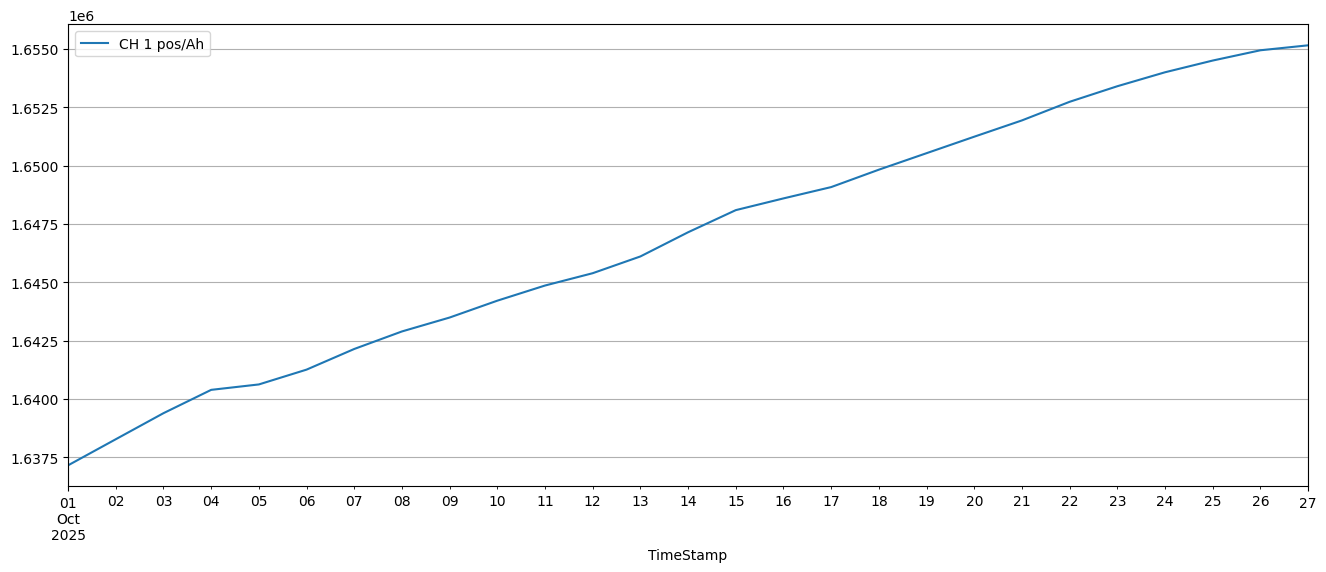

In [11]:
apu1 = energy_apu1.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
apu1['TimeStamp'] = pd.to_datetime(apu1['TimeStamp'])
apu1.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['CH 1 pos/Ah']
apu1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(350,400)
plt.show()
